# STARIT Tutorial: Nuclear–Perinuclear Localization-Marker Simulation Dataset

**Dataset 1; Supplementary Table 1**

This tutorial demonstrates how STARIT converts simulated image-based spatial transcriptomics (imSRT) molecular *x,y* coordinates into gene-specific raster images and how those images retain localization information during downstream analysis. The simulation dataset contains four known groups that differ in gene transcript abundance, gene spatial localization/organization, or both, without any added sparse-gene count noise. More information on STARIT and this datatset can be found in the [paper](https://doi.org/10.64898/2025.12.18.695193).

### Learning Objectives

By the end of the notebook, you will be able to:

1. rasterize transcript coordinates using STARIT
2. extract and concatenate gene-level ResNet-101 image features
3. compare unweighted and expression-weighted image representations
4. cluster cells with a k-nearest-neighbor graph and Louvain clustering and
5. compare image-based results with raw and scaled gene-count clustering

### Input Files

- `data/simulated_nuclear_peri/simulation_nuclear_peri_dataset.csv`: one transcript per row, with `x_position`, `y_position`, `gene_id`, `cell_id`, and `group_id`.
- `data/simulated_nuclear_peri/simulation_nuclear_peri_dataset_count_matrix.csv`: one cell per row, with its group and counts for `gene1`, `gene2`, and `gene3`.

Run the notebook from the repository root so these relative paths resolve correctly. The workflow is: environment setup → data inspection → STARIT rasterization → image-feature analysis → gene-counts analysis.

## 1. Reproducible Environment and Installation

The STARIT package itself requires only NumPy and Matplotlib. This tutorial also uses tabular-data, image-model, dimensionality-reduction, graph-clustering, and notebook packages for the downstream analysis. The versions below were read from the Anaconda `base` kernel in which these notebooks were developed.

| Software | Version in the tutorial kernel | Role in this notebook | Installation name |
|---|---:|---|---|
| Python | 3.11.7 | Runtime | `python` |
| Git | 2.50.1 (Apple Git-155) | Obtain and version the repository; not imported by Python | operating-system package |
| pip | 25.3 | Install Python packages | `pip` |
| STARIT | 0.1.0 | Rasterize spatial transcript coordinates | local project (`pip install -e .`) |
| NumPy | 1.26.4 | Arrays and numerical operations | `numpy` |
| Matplotlib | 3.8.0 | Image creation and plotting | `matplotlib` |
| pandas | 2.1.4 | Read and transform tabular data | `pandas` |
| Pillow | 10.2.0 | Load and pad images (`PIL`) | `pillow` |
| SciPy | 1.11.4 | Hungarian assignment | `scipy` |
| scikit-learn | 1.2.2 | PCA, t-SNE, nearest-neighbor graphs, and metrics | `scikit-learn` |
| NetworkX | 3.1 | Graph representation | `networkx` |
| python-louvain | 0.16 | Louvain community detection (`community.community_louvain`) | `python-louvain` |
| PyTorch | 2.7.1 | ResNet-101 inference | `torch` |
| TorchVision | 0.22.1 | Pretrained ResNet-101 and image transforms | `torchvision` |
| UMAP | 0.5.6 | Nonlinear two-dimensional embedding | `umap-learn` |
| natsort | 8.4.0 | Reproducible natural ordering of cell and gene names | `natsort` |
| JupyterLab | 4.0.11 | Notebook interface | `jupyterlab` |
| Notebook | 7.0.8 | Notebook document support | `notebook` |
| IPython kernel | 6.28.0 | Execute Python cells | `ipykernel` |

Git is a system tool rather than a Python dependency:
* **Windows:** Download and run the installer from [git-scm.com](https://git-scm.com/) or run `winget install --id Git.Git` in Command Prompt / PowerShell.
* **macOS:** Installing the Xcode Command Line Tools provides Git (`xcode-select --install`).
* **Debian/Ubuntu:** Use `sudo apt-get install git`.

Confirm the installation in your terminal with `git --version`.

To reproduce the Python environment with Conda, run the following commands in a terminal. Skip `git clone` if you already have the repository.

```bash
git clone https://github.com/JEFworks-Lab/STARIT.git
cd STARIT

conda create --name starit-tutorials python=3.11.7 pip=25.3
conda activate starit-tutorials

python -m pip install \
  numpy==1.26.4 matplotlib==3.8.0 pandas==2.1.4 pillow==10.2.0 \
  scipy==1.11.4 scikit-learn==1.2.2 networkx==3.1 \
  python-louvain==0.16 torch==2.7.1 torchvision==0.22.1 \
  umap-learn==0.5.6 natsort==8.4.0 \
  jupyterlab==4.0.11 notebook==7.0.8 ipykernel==6.28.0
python -m pip install -e .

python -m ipykernel install --user \
  --name starit-tutorials \
  --display-name "Python 3.11.7 (STARIT tutorials)"
jupyter lab
```

Select **Python 3.11.7 (STARIT tutorials)** as the notebook kernel, then restart the kernel after installation. The first execution of the ResNet101 cell may download pretrained weights (approximately 171 MB) if they are not already cached.

If you are running this notebook in **Google Colab** or a standalone **Jupyter Notebook**, execute the cell below to clone the repository, install the exact package versions, and set up STARIT in editable mode.

> **Note for Google Colab Users:** Google Colab comes with git pre-installed. Once the dependencies install, you may need to restart the runtime (**Runtime > Restart session**) for updated package versions to take effect.

In [1]:
# 1. Clone the repository (skip if running locally from within the cloned repository)
#!git clone https://github.com/JEFworks-Lab/STARIT.git
#%cd STARIT

# 2. Install required dependencies with exact pinned versions
"""
!python -m pip install \
  numpy==1.26.4 \
  matplotlib==3.8.0 \
  pandas==2.1.4 \
  pillow==10.2.0 \
  scipy==1.11.4 \
  scikit-learn==1.2.2 \
  networkx==3.1 \
  python-louvain==0.16 \
  torch==2.7.1 \
  torchvision==0.22.1 \
  umap-learn==0.5.6 \
  natsort==8.4.0
  """

# 3. Install the local STARIT package
#!python -m pip install -e ./*

'\n!python -m pip install   numpy==1.26.4   matplotlib==3.8.0   pandas==2.1.4   pillow==10.2.0   scipy==1.11.4   scikit-learn==1.2.2   networkx==3.1   python-louvain==0.16   torch==2.7.1   torchvision==0.22.1   umap-learn==0.5.6   natsort==8.4.0\n  '

## 2. Import Packages and Load the Simulation Dataset

First, we import the required packages to run this tutorial and fix the NumPy and PyTorch random seeds. The fixed seed improves repeatability for stochastic dimensionality-reduction and clustering steps. We also load both the simulated data and count matrix.

In [2]:
# Standard-library utilities
import os
import re

# Data handling and visualization
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from PIL import Image

# STARIT rasterization
from starit import get_bounding_box, save_image, starit

# Feature extraction, embedding, clustering, and evaluation
import community.community_louvain as cl
import umap
from natsort import natsorted
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, jaccard_score
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import LabelEncoder
import torch
from torchvision import models, transforms

# Fix stochastic components so repeated runs are comparable.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Select and load the noise-free simulation.
sim_data_folder = "simulated_nuclear_peri"

print("Loading dataset without noise.")
dataset = pd.read_csv(
    f"data/{sim_data_folder}/simulation_nuclear_peri_dataset.csv"
)
counts_matrix = pd.read_csv(
    f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix.csv",
    index_col=0,
)

Loading dataset without noise.


### Inspect the Data

The coordinate table should have one row per simulated transcript, whereas the count matrix should have one row per cell. Inspecting both the first rows and shapes, we can see what the data looks like before image generation begins.

In [3]:
# Inspect the transcript table and count matrix.
print("Dataset head:")
print(dataset.head())
print(dataset.shape)

print("\n")

print("Counts matrix head:")
print(counts_matrix.head())
print(counts_matrix.shape)

Dataset head:
   x_position  y_position gene_id  cell_id group_id
0         180         131   gene1        1   group1
1          88         129   gene1        1   group1
2         175         111   gene1        1   group1
3         125         172   gene1        1   group1
4          91         181   gene1        1   group1
(4000, 5)


Counts matrix head:
        group_id  gene1  gene2  gene3
cell_id                              
1         group1     50      0      0
2         group1     50      0      0
3         group1     50      0      0
4         group1     50      0      0
5         group1     50      0      0
(80, 4)


## 3. Get Bounding Box

STARIT images are comparable only when every cell is in the same coordinate space and each STARIT images maintains the same aspect ratio across all cells in the dataset. We therefore calculate one bounding box from all transcript coordinates and reuse it for every cell–gene image; this preserves location and scale across the dataset. Each cell’s transcripts are plotted at their true spatial coordinates within this shared coordinate system, ensuring that all images are aligned and visually comparable across cells or samples in the dataset.

In [4]:
# Calculate the shared spatial bounding box.
# Calculate one coordinate frame for the complete dataset.
bounding_box = get_bounding_box(dataset['x_position'], dataset['y_position'])
print("Bounding box [min_x, max_x, min_y, max_y]:")
print(bounding_box)

Bounding box [min_x, max_x, min_y, max_y]:
(30.599999999999994, 193.4, 31.599999999999994, 194.4)


## 4. STARIT Rasterization

For each group, cell, and gene, STARIT transforms *x,y* transcript coordinates into a gene tensor image. A black placeholder image is written when a cell–gene pair has no valid coordinates (no gene for that cell) so that every cell retains the same gene-channel layout, regardless of missing or empty data.

Rasterized images are written to `data/simulated_nuclear_peri/<group>/<cell>/<gene>.png`. The downstream cells in this Jupyter notebook analyze these STARIT images.

In [5]:
# Rasterize every cell-gene pair and create placeholders when needed.
# Process experimental groups in a reproducible order.
group_list = sorted(dataset["group_id"].dropna().unique().tolist())

image_size = (224, 224)
group_counts = {}

print(f"Generating STARIT and placeholder images for {len(group_list)} groups...")

for group_id in group_list:
    group_data = dataset[dataset["group_id"] == group_id]
    group_dir = os.path.join("data", sim_data_folder, str(group_id))
    os.makedirs(group_dir, exist_ok=True)

    group_cells = group_data["cell_id"].unique()
    group_genes = dataset["gene_id"].unique()
    total_images = 0

    print(f"\n Processing {group_id}: {len(group_cells)} cells x {len(group_genes)} genes")

    for cell_id in group_cells:
        # Store one subdirectory per cell.
        cell_dir = os.path.join(group_dir, f"cell{cell_id}")
        os.makedirs(cell_dir, exist_ok=True)

        for gene_id in group_genes:
            subset_data = group_data[
                (group_data["cell_id"] == cell_id) &
                (group_data["gene_id"] == gene_id)
            ]

            # Store one image per gene inside the cell directory.
            save_path = os.path.join(cell_dir, f"{gene_id}.png")

            if subset_data.empty or subset_data["x_position"].isna().all() or subset_data["y_position"].isna().all():
                fig, ax = plt.subplots(figsize=(image_size[0] / 100, image_size[1] / 100), dpi=100)
                ax.set_xlim(0, image_size[0])
                ax.set_ylim(0, image_size[1])
                ax.set_facecolor("black")
                ax.axis("off")
                fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="black")
                plt.close(fig)
                print(f"Placeholder saved for {group_id} | cell {cell_id}, gene {gene_id}")
            else:
                results = starit(
                    bounding_box,
                    subset_data["x_position"],
                    subset_data["y_position"],
                    dx=1.0,
                    blur=1.0,
                    draw=10000,
                    wavelet_magnitude=False,
                    use_windowing=True
                )
                save_image(results[2], save_path)
                plt.close(results[2])
                print(f"STARIT result saved for {group_id} | cell {cell_id}, gene {gene_id}")

            total_images += 1

    group_counts[group_id] = total_images
    print(f"Finished {group_id}: {total_images} total images generated.")

print("\n All groups processed successfully.")
print("Summary of images per group:", group_counts)

Generating STARIT and placeholder images for 4 groups...

 Processing group1: 20 cells x 3 genes
0 of 50
49 of 50
STARIT result saved for group1 | cell 1, gene gene1
Placeholder saved for group1 | cell 1, gene gene2
Placeholder saved for group1 | cell 1, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 2, gene gene1
Placeholder saved for group1 | cell 2, gene gene2
Placeholder saved for group1 | cell 2, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 3, gene gene1
Placeholder saved for group1 | cell 3, gene gene2
Placeholder saved for group1 | cell 3, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 4, gene gene1
Placeholder saved for group1 | cell 4, gene gene2
Placeholder saved for group1 | cell 4, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 5, gene gene1
Placeholder saved for group1 | cell 5, gene gene2
Placeholder saved for group1 | cell 5, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 6, 

## 5. Configure ResNet101 Feature Extraction & Helper Functions

Following STARIT rasterization, we set up a pipeline to extract STARIT image features using a pre-trained ResNet101 model. Prior to model input, each STARIT rasterized gene image was converted to RGB before the image was resized to 224x224 pixels with aspect-ratio preservation and padding. Images were normalized using ImageNet preprocessing parameters. Replacing ResNet-101's classification layer with an identity operation gives us a 2,048-value feature embedding for each gene image, which is what we want.

Here we also define various helper functions for our STARIT downstream analysis for this dataset used later in the notebook. To compare STARIT-derived clusters with ground-truth simulated groups, we computed a Jaccard similarity matrix. Cluster numbers are arbitrary, so the Hungarian algorithm finds the cluster-to-group assignment that maximizes total Jaccard overlap before a mean matched score is reported. When the number of inferred clusters differs from the number of ground-truth groups, mean on-diagonal Jaccard similarity was computed from the best one-to-one matching between groups and clusters, to get a sense of the clustering agreement. We define a heatmap visualization that shows the pairwise overlap between clusters and known simulation groups to help illustrate this.

In [6]:
# Match the ImageNet preprocessing used to train ResNet101.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# Remove the classifier so the network returns a 2,048-value image embedding.
resnet101 = models.resnet101(pretrained=True)
resnet101.fc = torch.nn.Identity()


def prepare_image_with_padding_pil(image_path, target_size=(224, 224)):
    """Resize an image without distortion and center it on a black canvas."""
    image = Image.open(image_path).convert("RGB")
    original_width, original_height = image.size
    target_width, target_height = target_size

    scale = min(target_width / original_width, target_height / original_height)
    new_width = int(original_width * scale)
    new_height = int(original_height * scale)
    resized_image = image.resize((new_width, new_height), Image.LANCZOS)

    padded_image = Image.new("RGB", target_size, (0, 0, 0))
    paste_x = (target_width - new_width) // 2
    paste_y = (target_height - new_height) // 2
    padded_image.paste(resized_image, (paste_x, paste_y))
    return padded_image


def extract_features(image_path, model):
    """Return the ResNet-101 embedding for one STARIT image."""
    padded_image = prepare_image_with_padding_pil(image_path, target_size=(224, 224))
    input_tensor = transform(padded_image)
    input_batch = input_tensor.unsqueeze(0)

    with torch.no_grad():
        return model(input_batch)


def calculate_jaccard_similarity(cluster_labels, annotations):
    """Calculate every cluster-to-annotation Jaccard overlap."""
    label_encoder = LabelEncoder()
    cluster_labels_encoded = label_encoder.fit_transform(cluster_labels)
    cluster_names = label_encoder.classes_
    annotations_encoded = label_encoder.fit_transform(annotations)
    annotation_names = label_encoder.classes_

    jaccard_matrix = np.zeros((len(cluster_names), len(annotation_names)))
    for cluster_index in range(len(cluster_names)):
        for annotation_index in range(len(annotation_names)):
            jaccard_matrix[cluster_index, annotation_index] = jaccard_score(
                cluster_labels_encoded == cluster_index,
                annotations_encoded == annotation_index,
            )

    return jaccard_matrix, cluster_names, annotation_names


def reorder_matrix_with_hungarian(matrix):
    """Find the cluster-to-annotation assignment with maximum total overlap."""
    cost_matrix = -matrix
    return linear_sum_assignment(cost_matrix)

    
def calculate_average_diagonal_jaccard(cluster_labels, true_labels):
    """Average the Jaccard scores under the optimal label assignment."""
    jaccard_matrix, _, _ = calculate_jaccard_similarity(cluster_labels, true_labels)
    row_indices, column_indices = linear_sum_assignment(-jaccard_matrix)
    matched_scores = jaccard_matrix[row_indices, column_indices]
    return np.mean(matched_scores), matched_scores

def plot_heatmap(similarity_matrix, labels1, labels2):
    """Plot a cluster-by-annotation Jaccard-similarity matrix."""
    plt.figure(figsize=(10, 8))
    plt.imshow(similarity_matrix, cmap="viridis", aspect="auto")
    plt.colorbar(label="Jaccard Similarity")
    plt.xticks(range(len(labels1)), labels1, rotation=45, ha="right")
    plt.yticks(range(len(labels2)), labels2)
    plt.xlabel("Annotations")
    plt.ylabel("Cluster Labels")
    plt.tight_layout()
    plt.show()

/Users/dvelazq5/.local/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/dvelazq5/.local/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Discover Ground-Truth Reference Annontation Labels

 Natural sorting keeps names such as `cell2` before `cell10`, and the enclosing group directory supplies the known ground-truth simulation label.

In [7]:
# Discover cell directories and retain their reference group labels.
data_folder = f"data/{sim_data_folder}"
folders = ['group1', 'group2', 'group3', 'group4']
file_list = []
annotations = []
id_list = [] # Initialize the new ID list

for folder in folders:
    folder_path = os.path.join(data_folder, folder)
    
    if os.path.exists(folder_path):
        #List all files in the folder
        files = os.listdir(folder_path)
        
        # Sort files to ensure a consistent order if needed (optional)
        sorted_files = natsorted(files)
        
        #Add filenames to the file_list and annotations to the annotations list
        for file in sorted_files:
            full_file_path = os.path.join(folder_path, file)
            file_list.append(full_file_path)
            annotations.append(folder)
            
            # Create the unique ID
            # Extract just the filename (e.g., 'cell19' from the path)
            cell_name = os.path.basename(file) 
            id_list.append(f"{folder}_{cell_name}")

print("File List:", file_list)
print("Annotations:", annotations)    
print(" IDs:", id_list) # Print the new ID list

print(len(file_list))
print(len(annotations))
print(len(id_list)) # Print the length of the new ID list

File List: ['data/simulated_nuclear_peri/group1/cell1', 'data/simulated_nuclear_peri/group1/cell2', 'data/simulated_nuclear_peri/group1/cell3', 'data/simulated_nuclear_peri/group1/cell4', 'data/simulated_nuclear_peri/group1/cell5', 'data/simulated_nuclear_peri/group1/cell6', 'data/simulated_nuclear_peri/group1/cell7', 'data/simulated_nuclear_peri/group1/cell8', 'data/simulated_nuclear_peri/group1/cell9', 'data/simulated_nuclear_peri/group1/cell10', 'data/simulated_nuclear_peri/group1/cell11', 'data/simulated_nuclear_peri/group1/cell12', 'data/simulated_nuclear_peri/group1/cell13', 'data/simulated_nuclear_peri/group1/cell14', 'data/simulated_nuclear_peri/group1/cell15', 'data/simulated_nuclear_peri/group1/cell16', 'data/simulated_nuclear_peri/group1/cell17', 'data/simulated_nuclear_peri/group1/cell18', 'data/simulated_nuclear_peri/group1/cell19', 'data/simulated_nuclear_peri/group1/cell20', 'data/simulated_nuclear_peri/group2/cell21', 'data/simulated_nuclear_peri/group2/cell22', 'data/s

### Encode the Reference Groups

The ground-truth labels are retained for agreement metrics and also mapped to integers for consistent plot colors. This conversion does not affect feature extraction or clustering.

In [8]:
# Store reference group labels as a NumPy array.
true_labels = np.array(annotations)

# Map reference group names to numeric labels for plotting.
group_to_num = {'group1': 1, 'group2': 2, 'group3': 3, 'group4': 4}
numeric_labels = np.array([group_to_num[g] for g in true_labels])
unique_labels = set(numeric_labels)

## 6. Unweighted STARIT Image Feature Extraction & Analysis

### Feature Extraction

Going through each group for each cell, we extract image features using ResNet101 for each gene image. ResNet101 produces one 2,048-value feature embedding per gene image. At the end, we concatenate all extracted feature vectors to yield a 2-D cell-by-feature matrix. Concatenating the three gene embeddings yields one 6,144-value row per cell, with dimension size `(80, 6,144)`. The first 2,048 features correspond to `gene1`, the next 2,048 features correspond to `gene2`, etc. At this stage, every gene contributes equally, regardless of its transcript count.

In [9]:
# Extract and concatenate one ResNet101 embedding per gene image.
features_stack = []
cell_id_list = [] # This will store the unique cell IDs (e.g., 'group1_cell1')
gene_image_order = {} # Dictionary to store cell_id: [list of gene image files]

for cell_folder_path in file_list: # file_list now contains paths like '/home/.../group1/cell1'
    features_list = []
    gene_files_for_cell = [] # To store gene image filenames for the current cell

    # Extract group and cell name to form the unique cell ID
    parts = cell_folder_path.split(os.sep) # Split by path separator
    group_name = parts[-2] # 'group1'
    cell_name = parts[-1]  # 'cell1'
    unique_cell_id = f"{group_name}_{cell_name}"
    
    # Store this unique_cell_id in the list that corresponds to `features_stack`
    cell_id_list.append(unique_cell_id)

    # List files inside the cell folder (which are the gene images)
    try:
        gene_image_files = os.listdir(cell_folder_path)
        # Ensure consistent order of gene images
        gene_image_files_sorted = natsorted(gene_image_files)  # Use natsorted for natural sorting
    except NotADirectoryError:
        print(f"Warning: '{cell_folder_path}' is not a directory. Skipping.")
        continue # Skip if it's not a directory (e.g., if file_list somehow contained actual image files instead of folders)


    for gene_file_name in gene_image_files_sorted:
        full_gene_image_path = os.path.join(cell_folder_path, gene_file_name)
        
        feat = extract_features(full_gene_image_path, resnet101)
        features_list.append(np.array(feat.squeeze()))
        gene_files_for_cell.append(gene_file_name) # Store just the filename

    if features_list:  # Ensure features exist before concatenation
        features_stack.append(np.concatenate(features_list, axis=0))
        # Store the list of gene files for this unique cell ID
        gene_image_order[unique_cell_id] = gene_files_for_cell
    else:
        print(f"Warning: No gene images found or processed for cell: {unique_cell_id}")


# Convert list to numpy array
if features_stack: # Ensure features_stack is not empty before stacking
    features_stack = np.stack(features_stack)
    print("Features Stack Shape:", features_stack.shape)
else:
    print("No features were extracted.")

print("\nCell ID List (for features_stack order):", cell_id_list)
print("\nGene Image Order (by Cell ID):")
for cell_id, gene_files in gene_image_order.items():
    print(f"  {cell_id}: {gene_files}")

print(f"\nNumber of cells with features extracted: {len(cell_id_list)}")
print(f"Number of entries in gene_image_order: {len(gene_image_order)}")

Features Stack Shape: (80, 6144)

Cell ID List (for features_stack order): ['group1_cell1', 'group1_cell2', 'group1_cell3', 'group1_cell4', 'group1_cell5', 'group1_cell6', 'group1_cell7', 'group1_cell8', 'group1_cell9', 'group1_cell10', 'group1_cell11', 'group1_cell12', 'group1_cell13', 'group1_cell14', 'group1_cell15', 'group1_cell16', 'group1_cell17', 'group1_cell18', 'group1_cell19', 'group1_cell20', 'group2_cell21', 'group2_cell22', 'group2_cell23', 'group2_cell24', 'group2_cell25', 'group2_cell26', 'group2_cell27', 'group2_cell28', 'group2_cell29', 'group2_cell30', 'group2_cell31', 'group2_cell32', 'group2_cell33', 'group2_cell34', 'group2_cell35', 'group2_cell36', 'group2_cell37', 'group2_cell38', 'group2_cell39', 'group2_cell40', 'group3_cell41', 'group3_cell42', 'group3_cell43', 'group3_cell44', 'group3_cell45', 'group3_cell46', 'group3_cell47', 'group3_cell48', 'group3_cell49', 'group3_cell50', 'group3_cell51', 'group3_cell52', 'group3_cell53', 'group3_cell54', 'group3_cell55'

### Dimensionality Reduction

With our cell-by-feature matrix, we can now begin our downstream analysis, starting with dimensionality reduction. First, we apply Principal Component Analysis (PCA) to compress the 6,144 image features into 5 components while preserving most of the variance. Then, we can apply t-SNE (t-Distributed Stochastic Neighbor Embedding) and UMAP (Uniform Manifold Approximation and Projection) to the principal components (PCs) to capture the complex, nonlinear relationships between samples. These embeddings also support visualization.

In [10]:
# Reduce the unweighted feature matrix with PCA, t-SNE, and UMAP.
# Perform PCA
pca = PCA(n_components=5, random_state=42)
pca.fit(features_stack)
pcs = pca.transform(features_stack)

# Compute a two-dimensional t-SNE embedding
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

# Compute a two-dimensional UMAP embedding
reducer = umap.UMAP(n_neighbors=30, min_dist=0.2, random_state=42) 
embedding_umap = reducer.fit_transform(pcs)

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


### Visualize the Ground-Truth Simulation Groups from Unweighted STARIT Image Features

We can visualize PCA, t-SNE, and UMAP embeddings (where each point is a cell) by their known group labels. Since this dataset has no noise (extra gene counts), we see distinct clusters in the plots, organizing based on their learned feature similarities.

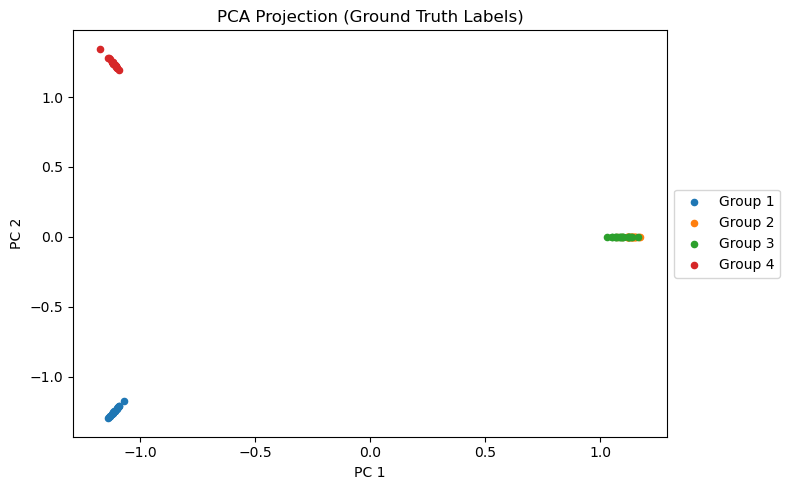

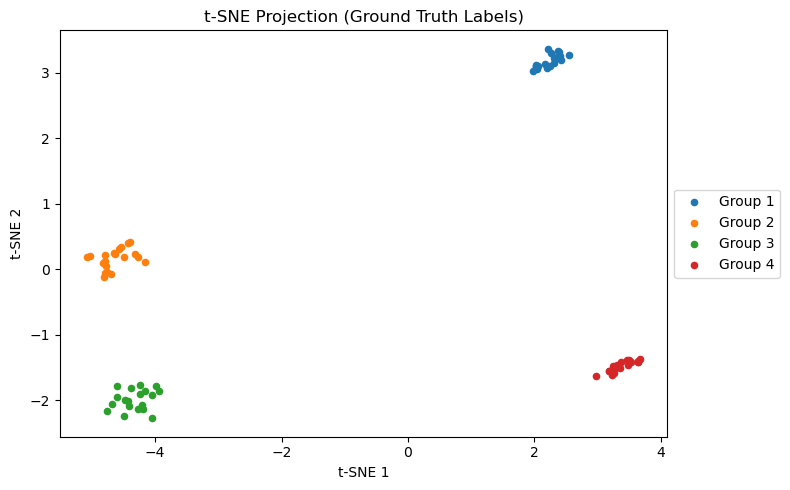

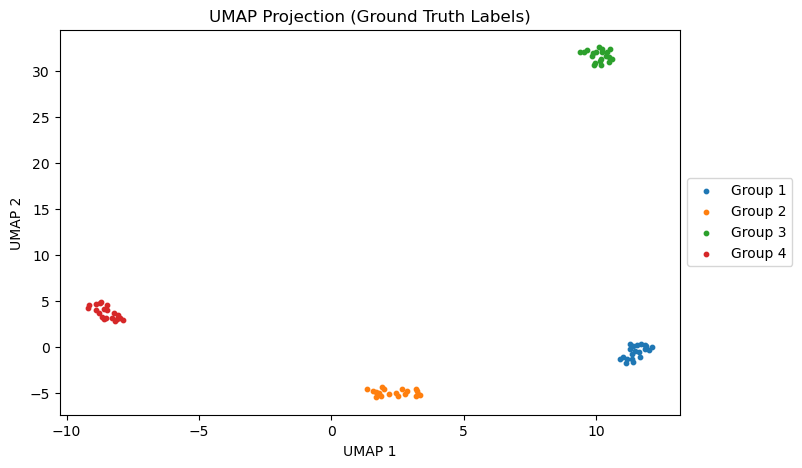

In [11]:
# Visualize each embedding using the known simulation groups.
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding_umap[mask, 0],
        embedding_umap[mask, 1],
        label=f'Group {group_label}',
        marker='o',
        s=10
    )
plt.title('UMAP Projection (Ground Truth Labels)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Louvain Clustering on Unweighted STARIT Features

We perform graph-based clustering on our PCs to observe how our clusters formed from our extracted image features correspond with our simulated ground-truth annontations. A k-nearest-neighbor (kNN) graph is constructed from cosine similarities between PCA scores. Louvain clustering was then applied to the resulting graph. The resulting clusters are projected onto all three embeddings for visualization.

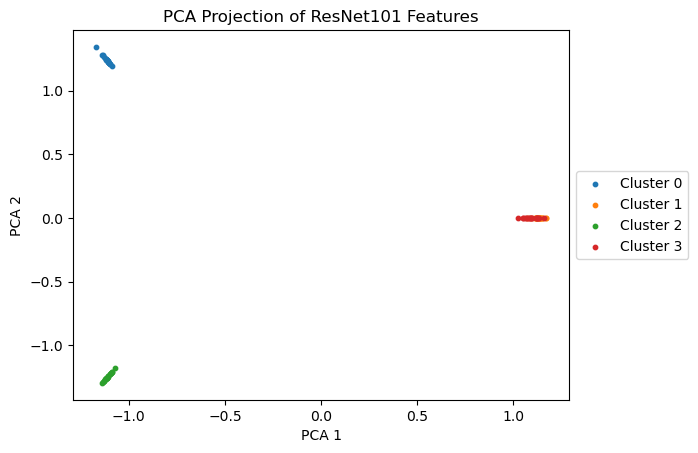

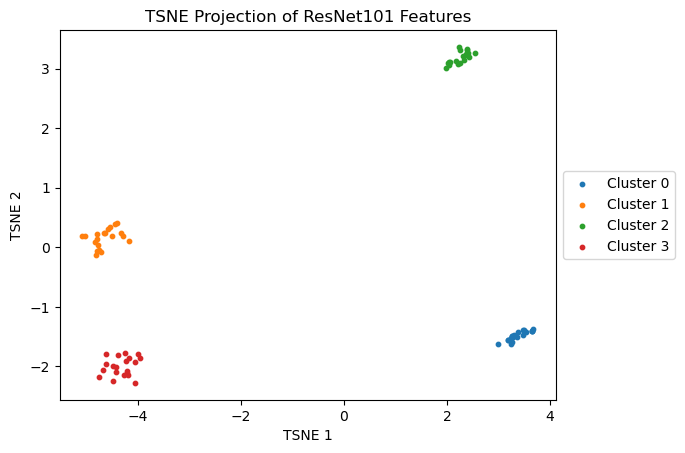

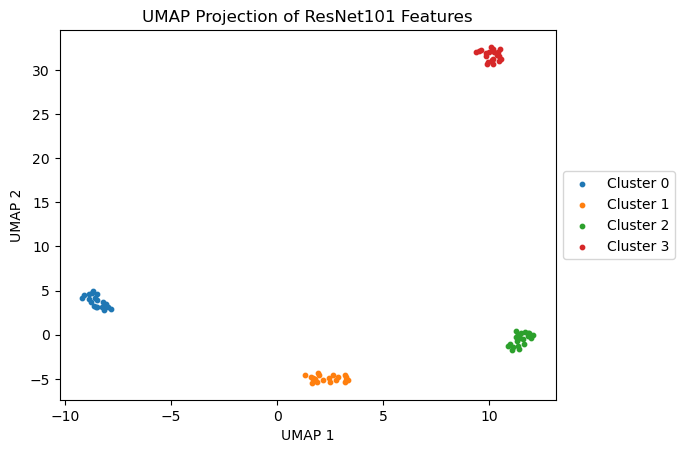

In [12]:
# Cluster the unweighted PCA representation with Louvain community detection.
# Construct a k-nearest-neighbor graph
knn_graph = kneighbors_graph(pcs, n_neighbors=18, metric='cosine', mode='connectivity', include_self=True)
# Convert the sparse adjacency matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)
# Detect graph communities with the Louvain algorithm
partition = cl.best_partition(G, random_state=42)
# Calculate partition modularity
cl.modularity(partition, G)
# Extract one cluster label per cell
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # TSNE 1 values for this cluster
        embedding[cluster_labels == label, 1],  # TSNE 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


for label in unique_labels_2:
    plt.scatter(
        embedding_umap[cluster_labels == label, 0],  # UMAP 1 values for this cluster
        embedding_umap[cluster_labels == label, 1],  # UMAP 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('UMAP Projection of ResNet101 Features')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Compare Clusters with the Ground-Truth Reference Groups

The Jaccard matrix is reordered with the Hungarian assignment so that the best cluster-to-group matches appear together.

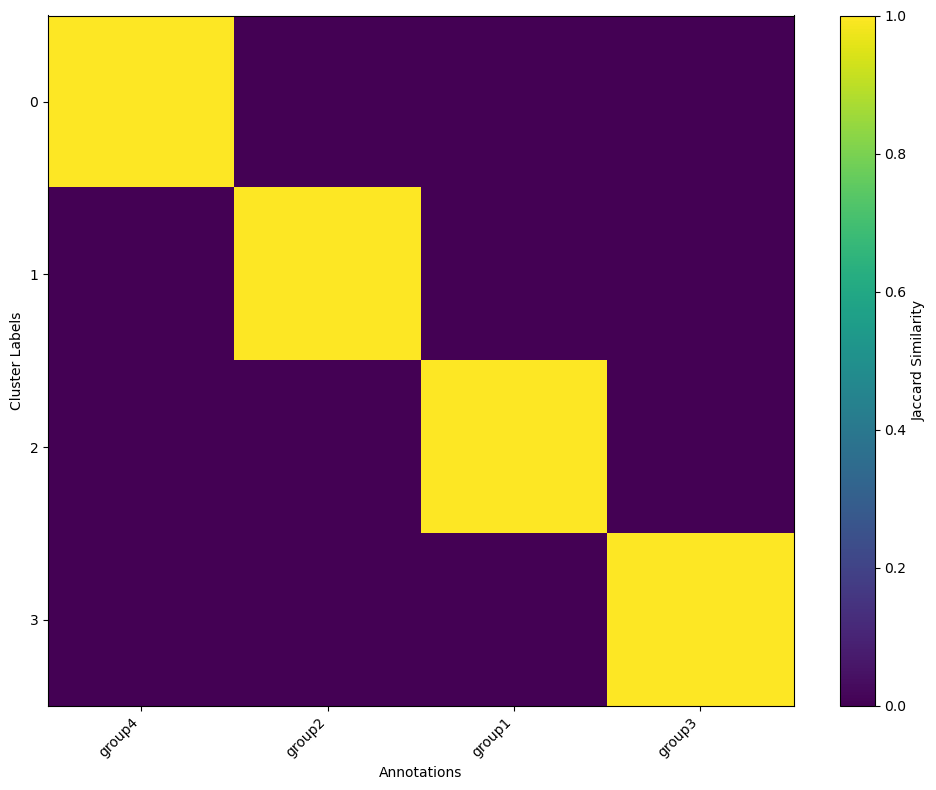

In [13]:
# Align clusters to annotations and display their Jaccard overlaps.
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
# Reorder the Jaccard similarity matrix using the Hungarian algorithm
row_ind, col_ind = reorder_matrix_with_hungarian(jaccard_matrix)
reordered_matrix = jaccard_matrix[row_ind][:, col_ind]

# Reorder labels
reordered_labels1 = [labels1[i] for i in row_ind]
reordered_labels2 = [labels2[i] for i in col_ind]
plot_heatmap(reordered_matrix, reordered_labels2, reordered_labels1)

### Report Agreement Metrics

The adjusted Rand index (ARI) measures pairwise agreement while correcting for chance. The matched Jaccard scores summarize membership overlap for the optimal cluster-to-group assignment. Values closer to 1 indicate stronger recovery of the simulated groups.

In [14]:
# Summarize agreement with ARI and optimally matched Jaccard scores.
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(np.array(annotations), cluster_labels)}")
average_jaccard, matched_scores = calculate_average_diagonal_jaccard(cluster_labels, np.array(annotations))
print(f"Matched Scores: {matched_scores}")
print(f"Average Diagonal Jaccard Similarity: {average_jaccard}")

Adjusted Rand Index (ARI): 1.0
Matched Scores: [1. 1. 1. 1.]
Average Diagonal Jaccard Similarity: 1.0


##### Interpretation
When we apply STARIT to this simulated noise-free imSRT dataset using the raw (unweighted) image features from ResNet101 followed by dimensionality reduction and Louvain graph-based clustering, we are able to identify four clusters of cells corresponding to the four simulated groups of cells representing cell-types and cell states with distinct subcellular heterogeneity. 

## 7. Weighted STARIT Image Feature Extraction & Analysis

Although this dataset has no noise and we are able to achieve perfect correspondence with our expected clustering and ground-truth, we will show how to integrate gene expression feature weighting into our STARIT analysis for this dataset. 

Extracted image feature capture spatial distribution and concentration of molecules within cells, while gene counts encode magnitude. Feature weighting combines these signals. To weight features, we take the original gene count matrix and apply min-max scaling on the counts seperately for each gene. During feature extraction, each 2,048-value gene embedding is multiplied by its cell-specific scaled count before the gene blocks are concatenated at the end.

### Scale the Gene-Count Matrix

Per-gene min-max scaling maps the observed counts to the interval [0, 1]. The scaled table is saved so that both weighting implementations and the scaled-count baseline use identical values.

In [15]:
# Min-max scale each gene's count vector across cells.
counts_matrix = pd.read_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix.csv", index_col=0)
scaled_counts_matrix = counts_matrix[["gene1", "gene2", "gene3"]]
# Scale each gene independently across cells.
def min_max_scaling(df):
    return (df - df.min()) / (df.max() - df.min())
scaled_counts_matrix = min_max_scaling(scaled_counts_matrix)
scaled_counts_matrix.to_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix_scaled.csv", index=True)

In [16]:
# Inspect the scaled count matrix.

print("Scaled counts matrix head:")
print(counts_matrix.head())
print(counts_matrix.shape)

print("\n")

print("=== SANITY CHECK 1: Min/Max Values ===")
print("Scaling by GENE - each column should have min=0, max=1:")
print(f"Column mins: {scaled_counts_matrix.min()}")
print(f"Column maxs: {scaled_counts_matrix.max()}")
print()

Scaled counts matrix head:
        group_id  gene1  gene2  gene3
cell_id                              
1         group1     50      0      0
2         group1     50      0      0
3         group1     50      0      0
4         group1     50      0      0
5         group1     50      0      0
(80, 4)


=== SANITY CHECK 1: Min/Max Values ===
Scaling by GENE - each column should have min=0, max=1:
Column mins: gene1    0.0
gene2    0.0
gene3    0.0
dtype: float64
Column maxs: gene1    1.0
gene2    1.0
gene3    1.0
dtype: float64



### Feature Extraction

Going through each group for each cell, we extract image features using ResNet101 for each gene image and multiply the embedding by its cell-specific scaled count. ResNet101 produces one 2,048-value feature embedding per gene image. At the end, we concatenate all extracted feature vectors to yield a 2-D cell-feature matrix. Concatenating the three gene embeddings yields one 6,144-value row per cell, with dimension size `(80, 6,144)`. The first 2,048 features correspond to `gene1`, the next 2,048 features correspond to `gene2`, etc. At this stage, every gene contributes equally, regardless of its transcript count.

Cell folder names are matched explicitly to count-matrix rows, and gene images are processed in count-matrix column order. These checks prevent silent misalignment between an image feature embedding and the weight applied to it. 

In [17]:
# Weight each gene-specific embedding before concatenation.
weighted_features_stack = []
cell_id_list = []
gene_image_order = {}

scaled_count_matrix = pd.read_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix_scaled.csv", index_col=0)
scaled_count_matrix.index = scaled_count_matrix.index.astype(str)
gene_names = list(scaled_count_matrix.columns)

for cell_folder_path in file_list:
    if not os.path.isdir(cell_folder_path):
        print(f"Warning: '{cell_folder_path}' is not a cell directory. Skipping.")
        continue

    group_name = os.path.basename(os.path.dirname(cell_folder_path))
    cell_name = os.path.basename(cell_folder_path)  # e.g. 'cell1'
    unique_cell_id = f"{group_name}_{cell_name}"

    # Folder names include the 'cell' prefix, while the count-matrix index does not.
    cell_match = re.fullmatch(r"cell(.+)", cell_name)
    if cell_match is None:
        print(f"Warning: Could not parse a cell ID from '{cell_name}'. Skipping.")
        continue

    matrix_cell_id = cell_match.group(1)
    if matrix_cell_id not in scaled_count_matrix.index:
        print(f"Warning: Cell ID '{matrix_cell_id}' was not found in the scaled count matrix. Skipping.")
        continue

    counts_for_cell = scaled_count_matrix.loc[matrix_cell_id]
    image_files_by_gene = {
        os.path.splitext(file_name)[0]: file_name
        for file_name in os.listdir(cell_folder_path)
        if os.path.isfile(os.path.join(cell_folder_path, file_name))
    }

    missing_genes = [gene_name for gene_name in gene_names if gene_name not in image_files_by_gene]
    if missing_genes:
        print(f"Warning: {unique_cell_id} is missing images for {missing_genes}. Skipping.")
        continue

    weighted_features_for_cell = []
    gene_files_for_cell = []

    # Use the scaled count-matrix column order so every concatenated vector has the same layout.
    for gene_name in gene_names:
        gene_file_name = image_files_by_gene[gene_name]
        full_gene_image_path = os.path.join(cell_folder_path, gene_file_name)
        gene_weight = float(counts_for_cell[gene_name])

        feat = extract_features(full_gene_image_path, resnet101) * gene_weight
        weighted_features_for_cell.append(np.array(feat.squeeze()))
        gene_files_for_cell.append(gene_file_name)

    weighted_features_stack.append(np.concatenate(weighted_features_for_cell, axis=0))
    cell_id_list.append(unique_cell_id)
    gene_image_order[unique_cell_id] = gene_files_for_cell

if weighted_features_stack:
    weighted_features_stack = np.stack(weighted_features_stack)
    print("Weighted Features Stack Shape:", weighted_features_stack.shape)
else:
    weighted_features_stack = np.empty((0, 0))
    print("No weighted features were extracted.")

print("\nCell ID List (weighted_features_stack order):", cell_id_list)
print("\nGene Image Order (count-matrix column order):")
for cell_id, gene_files in gene_image_order.items():
    print(f"  {cell_id}: {gene_files}")

print(f"\nNumber of cells with weighted features: {len(cell_id_list)}")
print(f"Number of entries in gene_image_order: {len(gene_image_order)}")

Weighted Features Stack Shape: (80, 6144)

Cell ID List (weighted_features_stack order): ['group1_cell1', 'group1_cell2', 'group1_cell3', 'group1_cell4', 'group1_cell5', 'group1_cell6', 'group1_cell7', 'group1_cell8', 'group1_cell9', 'group1_cell10', 'group1_cell11', 'group1_cell12', 'group1_cell13', 'group1_cell14', 'group1_cell15', 'group1_cell16', 'group1_cell17', 'group1_cell18', 'group1_cell19', 'group1_cell20', 'group2_cell21', 'group2_cell22', 'group2_cell23', 'group2_cell24', 'group2_cell25', 'group2_cell26', 'group2_cell27', 'group2_cell28', 'group2_cell29', 'group2_cell30', 'group2_cell31', 'group2_cell32', 'group2_cell33', 'group2_cell34', 'group2_cell35', 'group2_cell36', 'group2_cell37', 'group2_cell38', 'group2_cell39', 'group2_cell40', 'group3_cell41', 'group3_cell42', 'group3_cell43', 'group3_cell44', 'group3_cell45', 'group3_cell46', 'group3_cell47', 'group3_cell48', 'group3_cell49', 'group3_cell50', 'group3_cell51', 'group3_cell52', 'group3_cell53', 'group3_cell54', '

### Dimensionality Reduction

With our cell-by-feature matrix, we can now begin our downstream analysis, starting with dimensionality reduction. First, we apply Principal Component Analysis (PCA) to compress the 6,144 image features into 5 components while preserving most of the variance. Then, we can apply t-SNE (t-Distributed Stochastic Neighbor Embedding) and UMAP (Uniform Manifold Approximation and Projection) to the principal components (PCs) to capture the complex, nonlinear relationships between samples. These embeddings also support visualization.

In [18]:
# Reduce the directly weighted feature matrix.
# Perform PCA
pca = PCA(n_components=5, random_state=42)
pcs = pca.fit_transform(weighted_features_stack)
# Compute a two-dimensional t-SNE embedding
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)
# Compute a two-dimensional UMAP embedding
reducer = umap.UMAP(n_neighbors=10, min_dist=0.5, random_state=42) 
embedding_umap = reducer.fit_transform(pcs)

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


### Visualize the Ground-Truth Simulation Groups from Weighted STARIT Features

We can visualize PCA, t-SNE, and UMAP embeddings (where each point is a cell) by their known group labels. Since this dataset has no noise (no extra gene counts), we see distinct clusters in the plots, organizing based on their learned feature similarities. Hence, the weighted embedding plots are very similar to the unweighted plots.

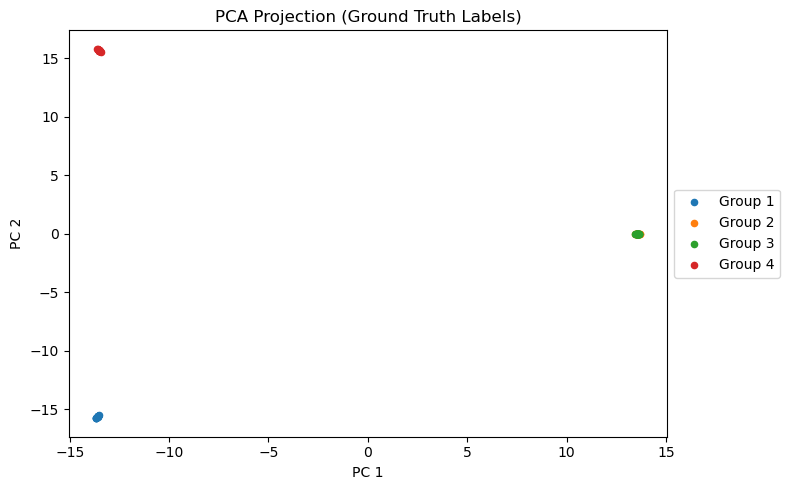

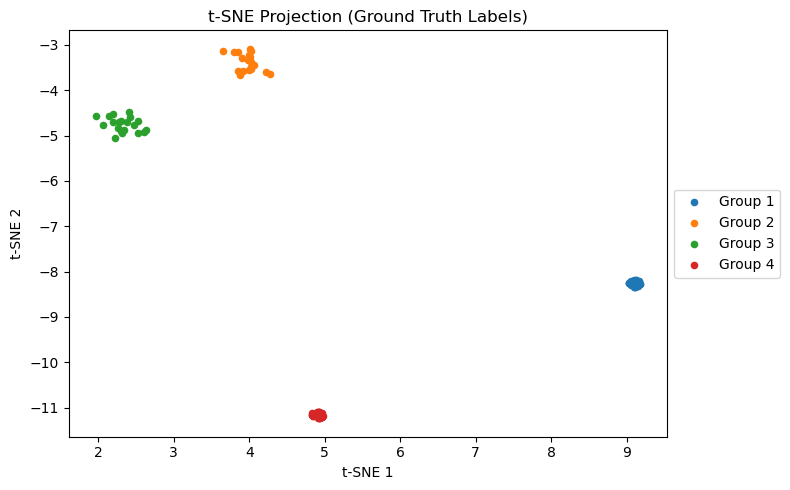

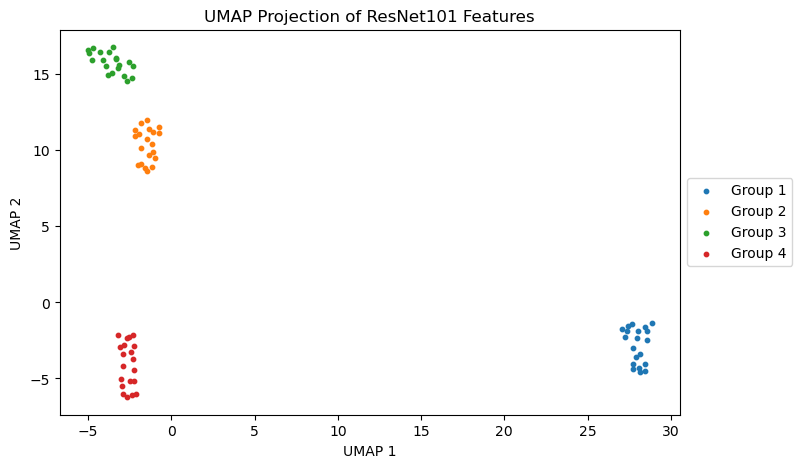

In [19]:
# Visualize the directly weighted embeddings by reference group.
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding_umap[mask, 0],
        embedding_umap[mask, 1],
        label=f'Group {group_label}',
        marker='o',
        s=10
    )
plt.title('UMAP Projection of ResNet101 Features')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Louvain Clustering on Weighted STARIT Features

We perform graph-based clustering on our PCs to observe how our clusters formed from our extracted image features correspond with our simulated ground-truth annontations. A k-nearest-neighbor (kNN) graph is constructed from cosine similarities between PCA scores. Louvain clustering was then applied to the resulting graph. The resulting clusters are projected onto all three embeddings for visualization.

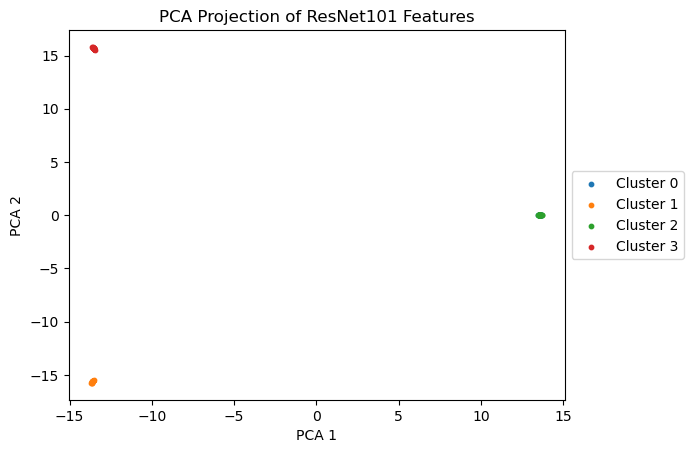

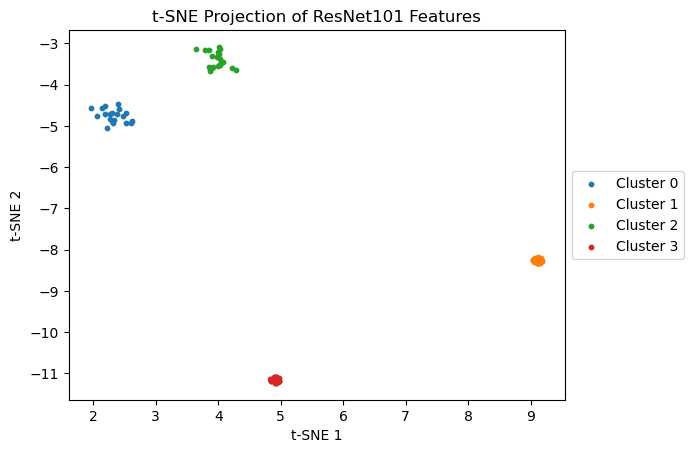

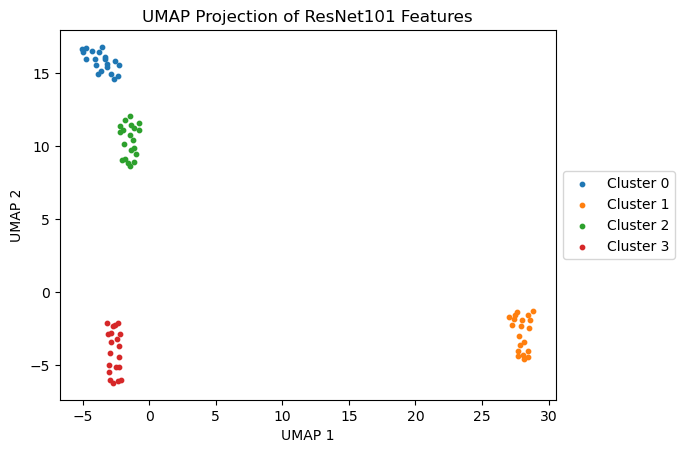

In [20]:
# Cluster the directly weighted PCA representation.
# Construct a k-nearest-neighbor graph
knn_graph = kneighbors_graph(pcs, n_neighbors=18, metric='cosine', mode='connectivity', include_self=True)
# Convert the sparse adjacency matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)
# Detect graph communities with the Louvain algorithm
partition = cl.best_partition(G, random_state=42)
# Calculate partition modularity
cl.modularity(partition, G)
# Extract one cluster label per cell
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # t-SNE 1 values for this cluster
        embedding[cluster_labels == label, 1],  # t-SNE 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('t-SNE Projection of ResNet101 Features')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


for label in unique_labels_2:
    plt.scatter(
        embedding_umap[cluster_labels == label, 0],  # UMAP 1 values for this cluster
        embedding_umap[cluster_labels == label, 1],  # UMAP 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('UMAP Projection of ResNet101 Features')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Compare Clusters with the Ground-Truth Reference Groups

The Jaccard matrix is reordered with the Hungarian assignment so that the best cluster-to-group matches appear together.

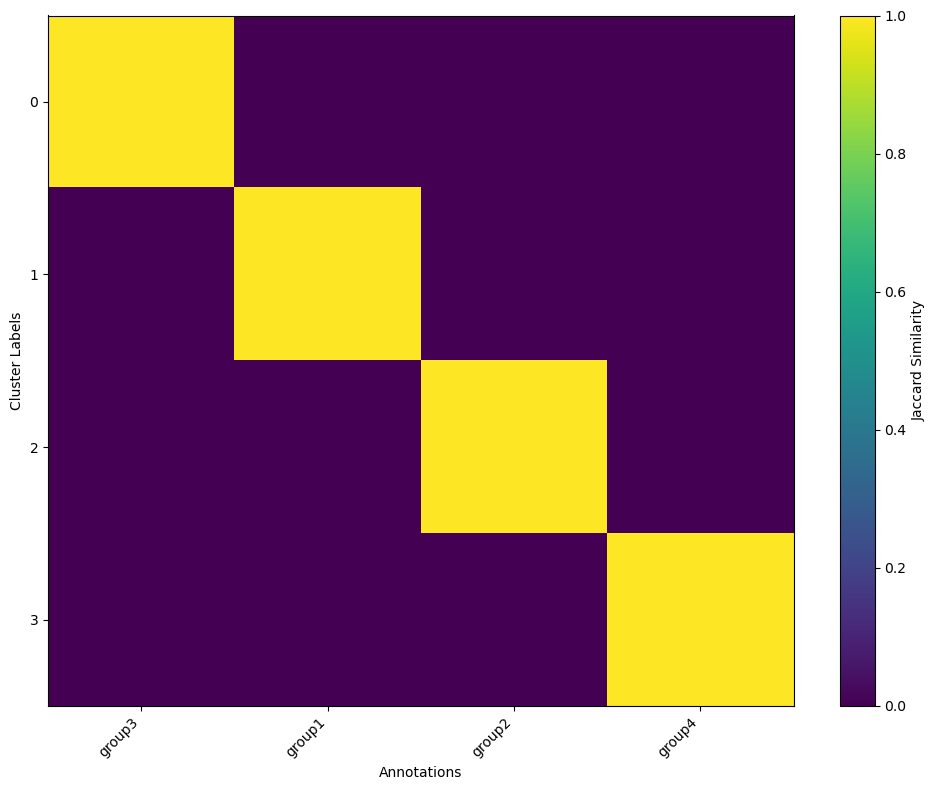

In [21]:
# Display cluster-to-annotation overlap for the directly weighted features.
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
# Reorder the Jaccard similarity matrix using the Hungarian algorithm
row_ind, col_ind = reorder_matrix_with_hungarian(jaccard_matrix)
reordered_matrix = jaccard_matrix[row_ind][:, col_ind]

# Reorder labels
reordered_labels1 = [labels1[i] for i in row_ind]
reordered_labels2 = [labels2[i] for i in col_ind]
plot_heatmap(reordered_matrix, reordered_labels2, reordered_labels1)

### Report Agreement Metrics

The adjusted Rand index (ARI) measures pairwise agreement while correcting for chance. The matched Jaccard scores summarize membership overlap for the optimal cluster-to-group assignment. Values closer to 1 indicate stronger recovery of the simulated groups.

In [22]:
# Report agreement metrics for the directly weighted features.
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(np.array(annotations), cluster_labels)}")
average_jaccard, matched_scores = calculate_average_diagonal_jaccard(cluster_labels, np.array(annotations))
print(f"Matched Scores: {matched_scores}")
print(f"Average Diagonal Jaccard Similarity: {average_jaccard}")

Adjusted Rand Index (ARI): 1.0
Matched Scores: [1. 1. 1. 1.]
Average Diagonal Jaccard Similarity: 1.0


## 8. Weighted STARIT Image Feature Extraction & Analysis (Alternative)

An alternative way to apply feature weighting to our cell-by-feature matrix (rather than performing feature extraction all over again) is to multiply the unweighted cell-by-feature matrix and scaled gene counts matrix directly through a **vectorized broadcasting operation**.  When every cell has exactly three ordered gene images, the unweighted matrix can be reshaped to `(80 cells, 3 genes, 2,048 features)` and multiplied by the scaled count matrix in one vectorized operation. 

Note this can not always be done. In this dataset, we know the order of the genes, the ResNet101 feature embedding (hence which extracted features coresspond to which cell), and that the genes are in the same order in the count matrix. The former method for feature weighting is safer for datasets with missing or variable gene panels, albeit this operation may save computation time. 

### Feature Extraction

In [23]:
# Apply the same gene weights by vectorized broadcasting.
scaled_count_matrix = pd.read_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix_scaled.csv", index_col=0)

# Reshape the concatenated embeddings into three 2,048-value gene blocks.
feat_reshaped = np.array(features_stack).reshape(80, 3, 2048)  # shape (80, 3, 2048)

# Multiply each chunk by the corresponding value in counts_matrix_np_scaled
# Broadcasting automatically expands counts_matrix_np_scaled along the last dimension
weighted_features_stack = feat_reshaped * np.asarray(scaled_counts_matrix)[:, :, np.newaxis]  # shape (80, 3, 2048)

# Flatten the weighted gene blocks back into one vector per cell.
weighted_features_stack = weighted_features_stack.reshape(80, 6144)

### Dimensionality Reduction

With our cell-by-feature matrix, we can now begin our downstream analysis, starting with dimensionality reduction. First, we apply Principal Component Analysis (PCA) to compress the 6,144 image features into 5 components while preserving most of the variance. Then, we can apply t-SNE (t-Distributed Stochastic Neighbor Embedding) and UMAP (Uniform Manifold Approximation and Projection) to the principal components (PCs) to capture the complex, nonlinear relationships between samples. These embeddings also support visualization.

In [24]:
# Reduce the vectorized weighted feature matrix.
# Perform PCA
pca = PCA(n_components=5, random_state=42)
pcs = pca.fit_transform(weighted_features_stack)
# Compute a two-dimensional t-SNE embedding
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)
# Compute a two-dimensional UMAP embedding
reducer = umap.UMAP(n_neighbors=30, min_dist=0.2, random_state=42) 
embedding_umap = reducer.fit_transform(pcs)

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


### Visualize the Ground-Truth Simulation Groups from Weighted STARIT Features (Alternative)

We can visualize PCA, t-SNE, and UMAP embeddings (where each point is a cell) by their known group labels. Since this dataset has no noise (no extra gene counts), we see distinct clusters in the plots, organizing based on their learned feature similarities. Hence, the weighted embedding plots are very similar to the unweighted plots.

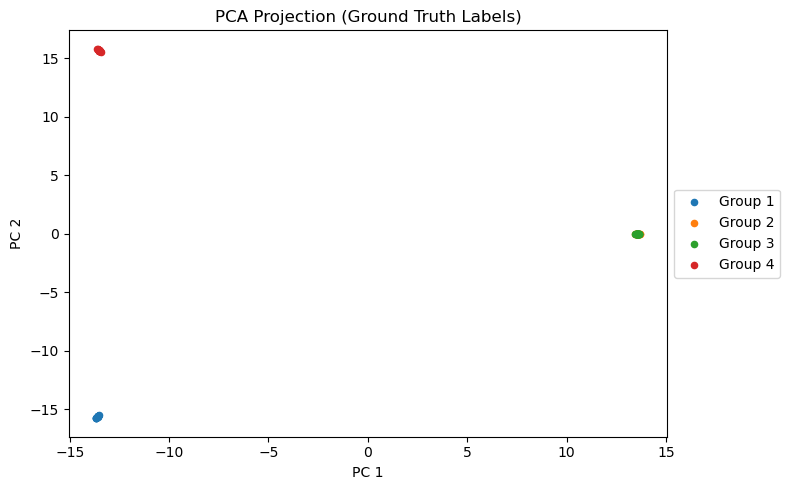

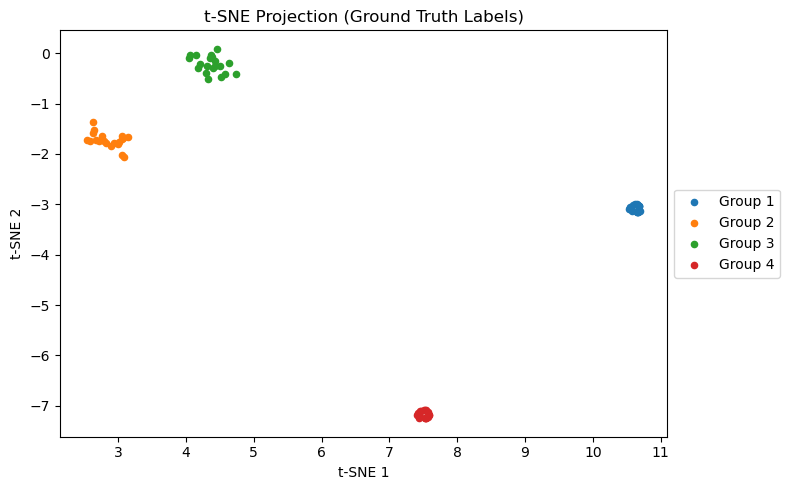

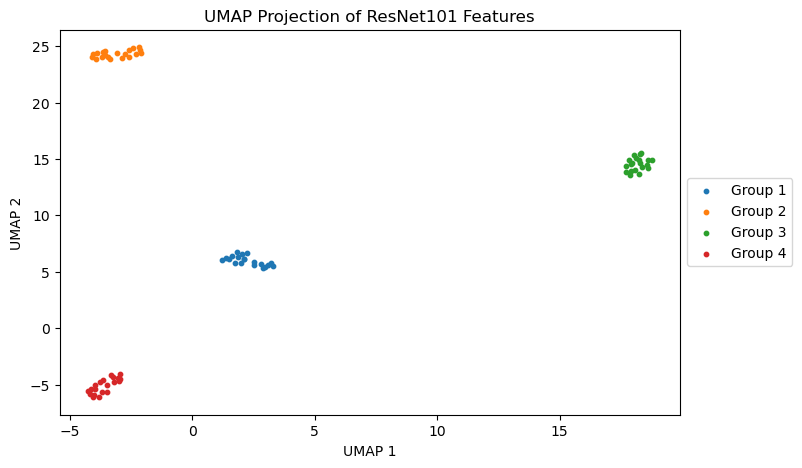

In [25]:
# Visualize the vectorized weighted embeddings by reference group.
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding_umap[mask, 0],
        embedding_umap[mask, 1],
        label=f'Group {group_label}',
        marker='o',
        s=10
    )
plt.title('UMAP Projection of ResNet101 Features')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Louvain Clustering on Weighted STARIT Features (Alternative)

We perform graph-based clustering on our PCs to observe how our clusters formed from our extracted image features correspond with our simulated ground-truth annontations. A k-nearest-neighbor (kNN) graph is constructed from cosine similarities between PCA scores. Louvain clustering was then applied to the resulting graph. The resulting clusters are projected onto all three embeddings for visualization.

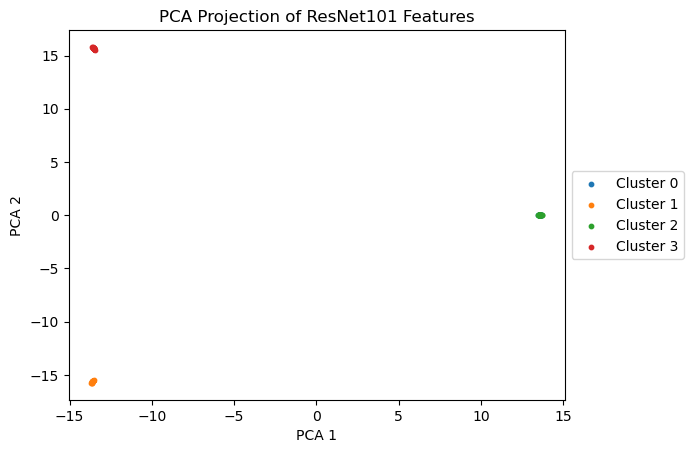

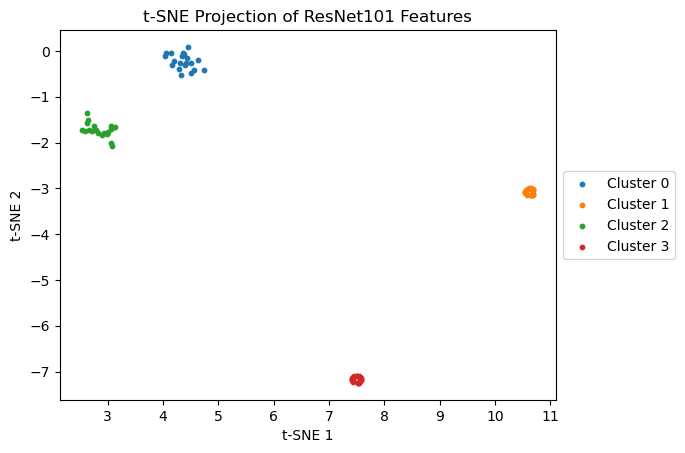

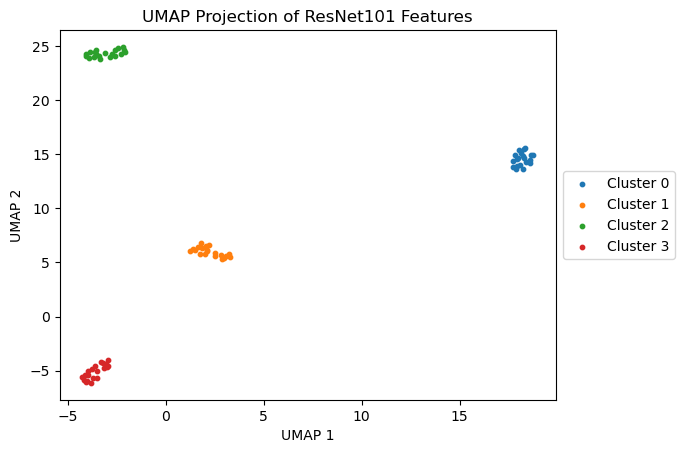

In [26]:
# Cluster the vectorized weighted PCA representation.
# Construct a k-nearest-neighbor graph
knn_graph = kneighbors_graph(pcs, n_neighbors=18, metric='cosine', mode='connectivity', include_self=True)
# Convert the sparse adjacency matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)
# Detect graph communities with the Louvain algorithm
partition = cl.best_partition(G, random_state=42)
# Calculate partition modularity
cl.modularity(partition, G)
# Extract one cluster label per cell
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # t-SNE 1 values for this cluster
        embedding[cluster_labels == label, 1],  # t-SNE 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('t-SNE Projection of ResNet101 Features')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


for label in unique_labels_2:
    plt.scatter(
        embedding_umap[cluster_labels == label, 0],  # UMAP 1 values for this cluster
        embedding_umap[cluster_labels == label, 1],  # UMAP 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('UMAP Projection of ResNet101 Features')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Compare Clusters with the Ground-Truth Reference Groups

The Jaccard matrix is reordered with the Hungarian assignment so that the best cluster-to-group matches appear together.

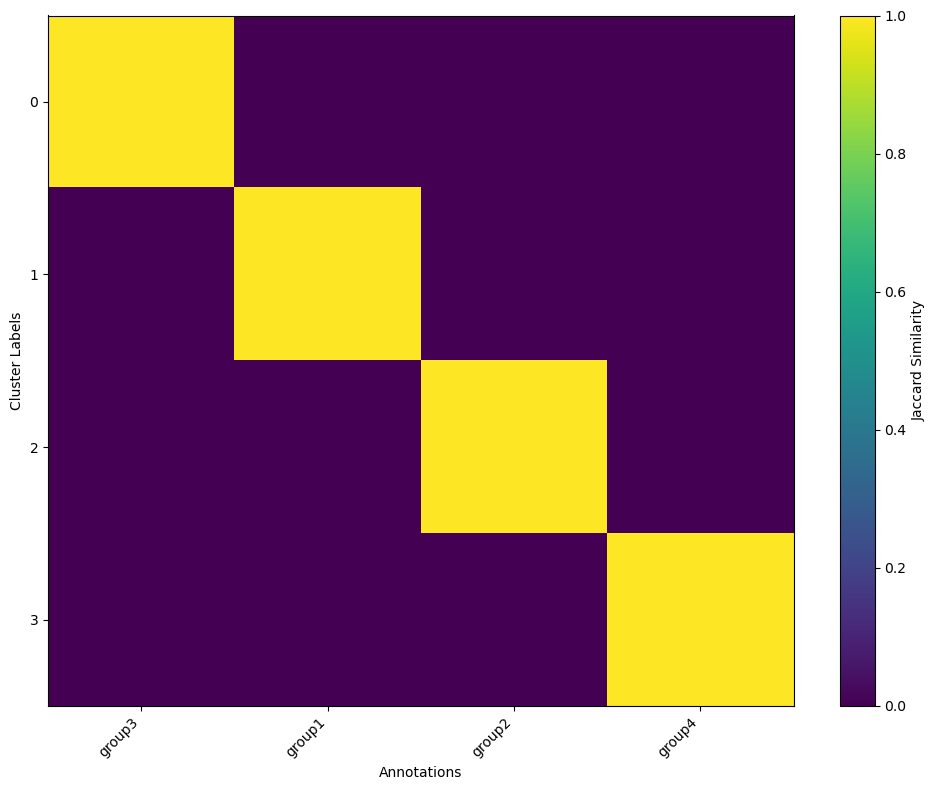

In [27]:
# Display cluster-to-annotation overlap for vectorized weighting.
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
# Reorder the Jaccard similarity matrix using the Hungarian algorithm
row_ind, col_ind = reorder_matrix_with_hungarian(jaccard_matrix)
reordered_matrix = jaccard_matrix[row_ind][:, col_ind]

# Reorder labels
reordered_labels1 = [labels1[i] for i in row_ind]
reordered_labels2 = [labels2[i] for i in col_ind]
plot_heatmap(reordered_matrix, reordered_labels2, reordered_labels1)

### Report Agreement Metrics

The adjusted Rand index (ARI) measures pairwise agreement while correcting for chance. The matched Jaccard scores summarize membership overlap for the optimal cluster-to-group assignment. Values closer to 1 indicate stronger recovery of the simulated groups.

In [28]:
# Report agreement metrics for vectorized weighting.
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(np.array(annotations), cluster_labels)}")
average_jaccard, matched_scores = calculate_average_diagonal_jaccard(cluster_labels, np.array(annotations))
print(f"Matched Scores: {matched_scores}")
print(f"Average Diagonal Jaccard Similarity: {average_jaccard}")

Adjusted Rand Index (ARI): 1.0
Matched Scores: [1. 1. 1. 1.]
Average Diagonal Jaccard Similarity: 1.0


##### Interpretation

In this noise-free simulation data, spatially distinct groups are already recoverable from the unweighted STARIT features alone. Feature weighting is included to demonstrate the method and to provide a direct comparison with the sparse-noise tutorial, where feature weighting information becomes more useful.

## 9. Gene Count Clustering Comparison

To demonstrate the advantage of using STARIT images for downstream analysis, we can apply the same analysis pipeline to the original gene counts matrix. The final analyses  discard spatial coordinates and use only the three gene counts per cell. Groups 2 and 3 have similar total transcript profiles but different nuclear versus perinuclear localization, so a count-only representation is not expected to separate them as reliably as STARIT image features.

### Raw Gene Counts

#### Dimensionality Reduction

With our gene count matrix, we can already begin our downstream analysis, starting with dimensionality reduction. First, we apply Principal Component Analysis (PCA) to the unscaled three-gene count matrix into 3 components while preserving most of the variance. Then, we can apply t-SNE (t-Distributed Stochastic Neighbor Embedding) and UMAP (Uniform Manifold Approximation and Projection) to the principal components (PCs) to capture the complex, nonlinear relationships between samples. These embeddings also support visualization.

In [29]:
# Reduce the raw three-gene count matrix.
counts_matrix = pd.read_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix.csv", index_col=0)
counts_matrix_np = counts_matrix[["gene1", "gene2", "gene3"]].to_numpy()

# Perform PCA
pca = PCA(n_components=3, random_state=42)
pca.fit(counts_matrix_np)
pcs = pca.transform(counts_matrix_np)

# Compute a two-dimensional t-SNE embedding
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

reducer = umap.UMAP(n_neighbors=20, min_dist=0.5, random_state=42)
embedding_umap = reducer.fit_transform(pcs)

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


#### Visualize the Ground-Truth Simulation Groups from Raw Gene Counts

We can visualize PCA, t-SNE, and UMAP embeddings (where each point is a cell) by their known group labels. Since this dataset has no noise (no extra gene counts), we only see distinct clusters in the plots. However instead of four groups, we only see three, organizing based on gene expression alone and neglecting the subcellular organization of Groups 2 & 3.

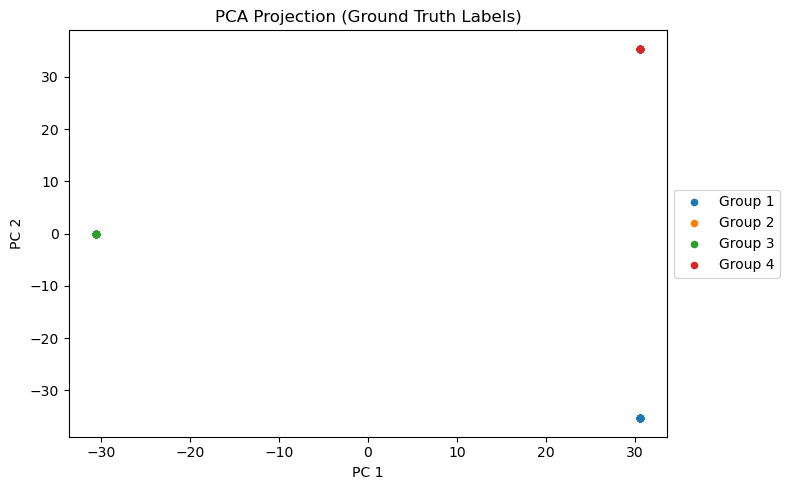

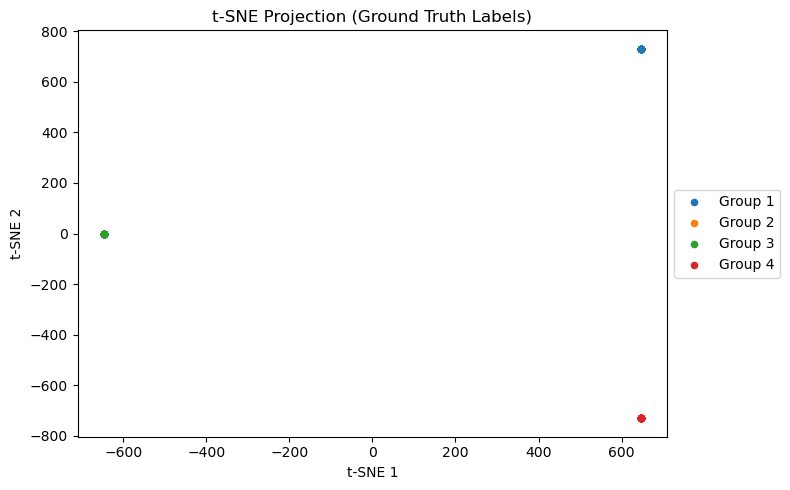

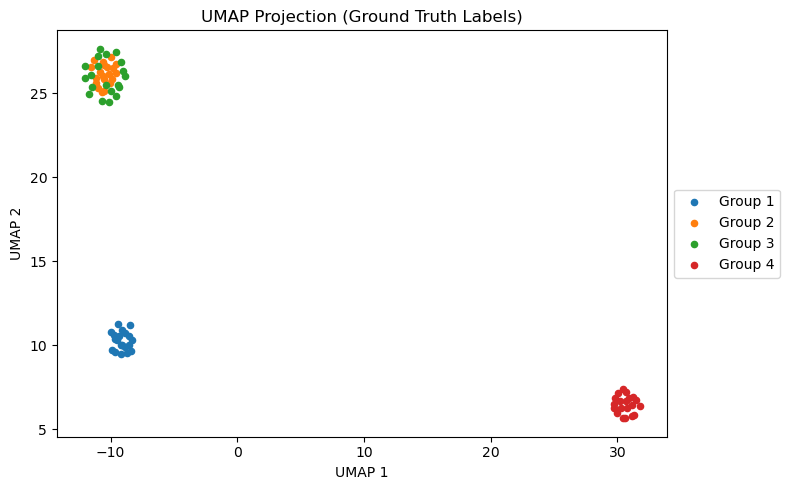

In [ ]:
# Visualize the raw-count embeddings by reference group.
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding_umap[mask, 0],  # UMAP dimension 1
        embedding_umap[mask, 1],  # UMAP dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('UMAP Projection (Ground Truth Labels)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#### Louvain Clustering on Raw Gene Counts

We perform graph-based clustering on our PCs to observe how our clusters formed from our raw gene counts correspond with our simulated ground-truth annontations. A k-nearest-neighbor (kNN) graph is constructed from cosine similarities between PCA scores. Louvain clustering was then applied to the resulting graph. The resulting clusters are projected onto all three embeddings for visualization.

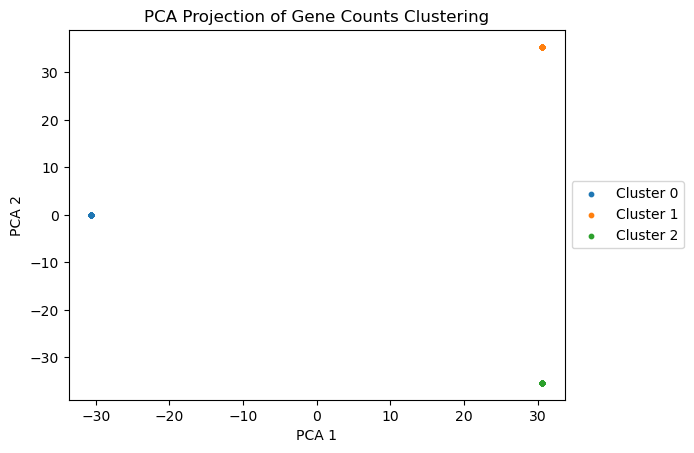

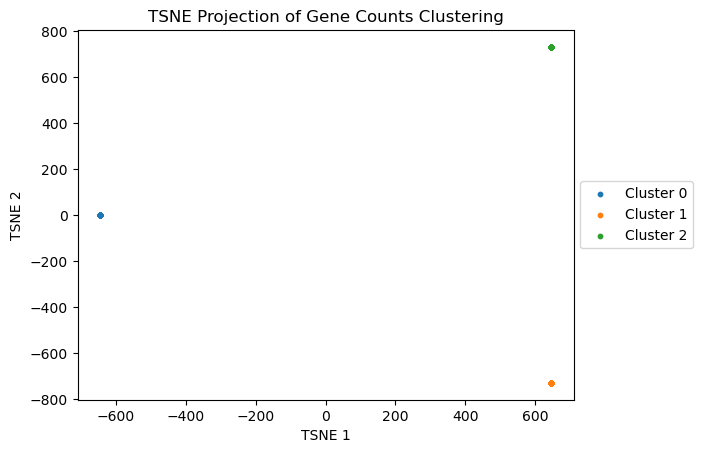

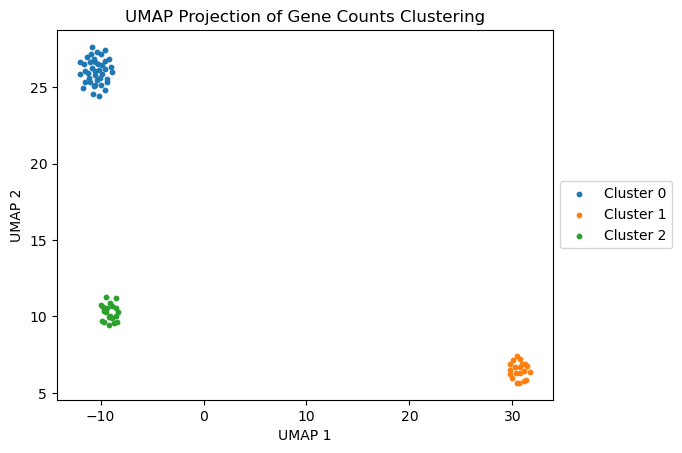

In [31]:
# Cluster the raw-count PCA representation.
# Construct a k-nearest-neighbor graph
knn_graph = kneighbors_graph(pcs, n_neighbors=20, metric='cosine', mode='connectivity', include_self=True)
# Convert the sparse adjacency matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)
# Detect graph communities with the Louvain algorithm
partition = cl.best_partition(G, random_state=42)  # Using a fixed random state for reproducibility
# Calculate partition modularity
cl.modularity(partition, G)
# Extract one cluster label per cell
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of Gene Counts Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # TSNE 1 values for this cluster
        embedding[cluster_labels == label, 1],  # TSNE 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of Gene Counts Clustering')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding_umap[cluster_labels == label, 0],  # UMAP 1 values for this cluster
        embedding_umap[cluster_labels == label, 1],  # UMAP 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('UMAP Projection of Gene Counts Clustering')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

#### Compare Clusters with the Ground-Truth Reference Groups

The Jaccard matrix is reordered with the Hungarian assignment so that the best cluster-to-group matches appear together.

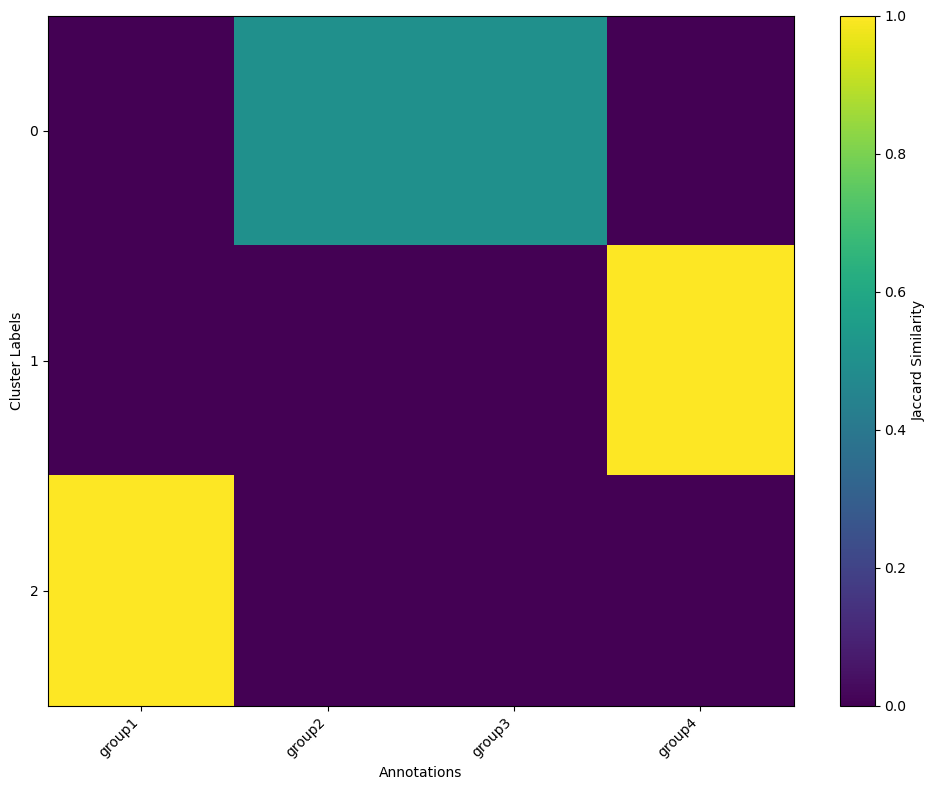

In [32]:
# Display cluster-to-annotation overlap for raw counts.
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

#### Report Agreement Metrics

The adjusted Rand index (ARI) measures pairwise agreement while correcting for chance. The matched Jaccard scores summarize membership overlap for the optimal cluster-to-group assignment. Values closer to 1 indicate stronger recovery of the simulated groups.

In [33]:
# Report agreement metrics for raw counts.
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(np.array(annotations), cluster_labels)}")
average_jaccard, matched_scores = calculate_average_diagonal_jaccard(cluster_labels, np.array(annotations))
print(f"Matched Scores: {matched_scores}")
print(f"Average Diagonal Jaccard Similarity: {average_jaccard}")

Adjusted Rand Index (ARI): 0.7063197026022305
Matched Scores: [0.5 1.  1. ]
Average Diagonal Jaccard Similarity: 0.8333333333333334


### Scaled Gene Counts

Repeats the analysis after per-gene min-max scaling. Scaling balances gene ranges but cannot restore nuclear-versus-perinuclear information that is absent from the count matrix.

#### Dimensionality Reduction

With our gene count matrix, we can already begin our downstream analysis, starting with dimensionality reduction. First, we apply Principal Component Analysis (PCA) to the unscaled three-gene count matrix into 3 components while preserving most of the variance. Then, we can apply t-SNE (t-Distributed Stochastic Neighbor Embedding) and UMAP (Uniform Manifold Approximation and Projection) to the principal components (PCs) to capture the complex, nonlinear relationships between samples. These embeddings also support visualization.

In [34]:
# Reduce the min-max-scaled count matrix.
scaled_counts_matrix = pd.read_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix_scaled.csv", index_col=0)
scaled_counts_matrix_np = scaled_counts_matrix.to_numpy()

# Perform PCA
pca = PCA(n_components=3, random_state=42)
pcs = pca.fit_transform(scaled_counts_matrix_np)

# Compute a two-dimensional t-SNE embedding
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

reducer = umap.UMAP(n_neighbors=20, min_dist=0.5, random_state=42)
embedding_umap = reducer.fit_transform(pcs)

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


#### Visualize the Ground-Truth Simulation Groups from Scaled Gene Counts

We can visualize PCA, t-SNE, and UMAP embeddings (where each point is a cell) by their known group labels. Since this dataset has no noise (no extra gene counts), we only see distinct clusters in the plots. However instead of four groups, we only see three, organizing based on gene expression alone and neglecting the subcellular organization of Groups 2 & 3.

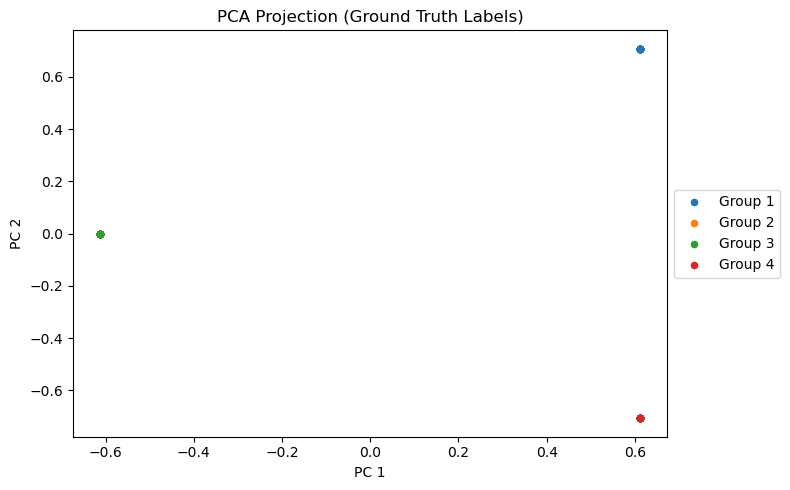

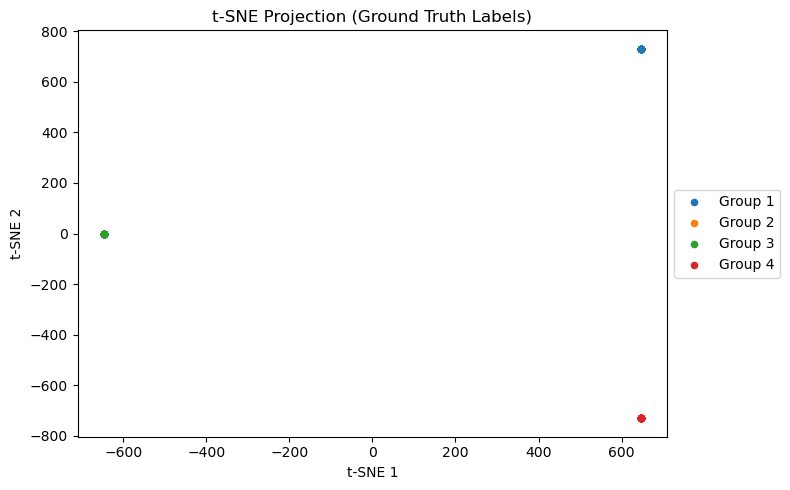

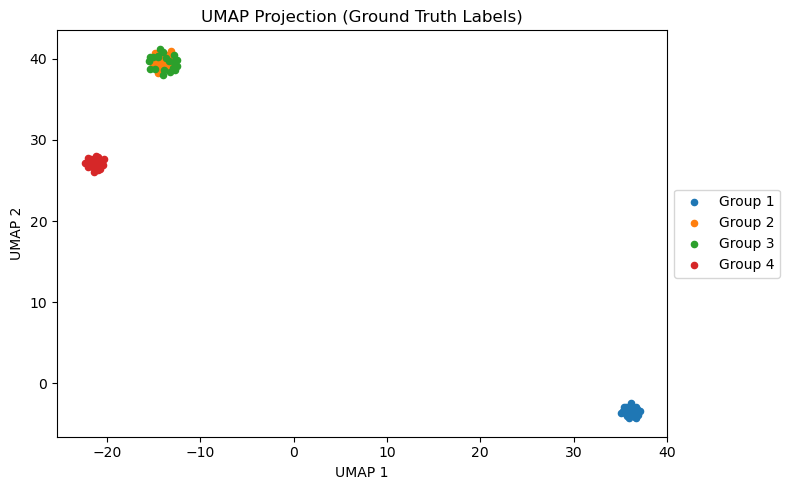

In [35]:
# Visualize the scaled-count embeddings by reference group.
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding_umap[mask, 0],  # t-SNE dimension 1
        embedding_umap[mask, 1],  # t-SNE dimension 2
        label=f'Group {group_label}',
        s=20
    )
plt.title('UMAP Projection (Ground Truth Labels)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#### Louvain Clustering on Scaled Gene Counts

We perform graph-based clustering on our PCs to observe how our clusters formed from our scaled gene counts correspond with our simulated ground-truth annontations. A k-nearest-neighbor (kNN) graph is constructed from cosine similarities between PCA scores. Louvain clustering was then applied to the resulting graph. The resulting clusters are projected onto all three embeddings for visualization.

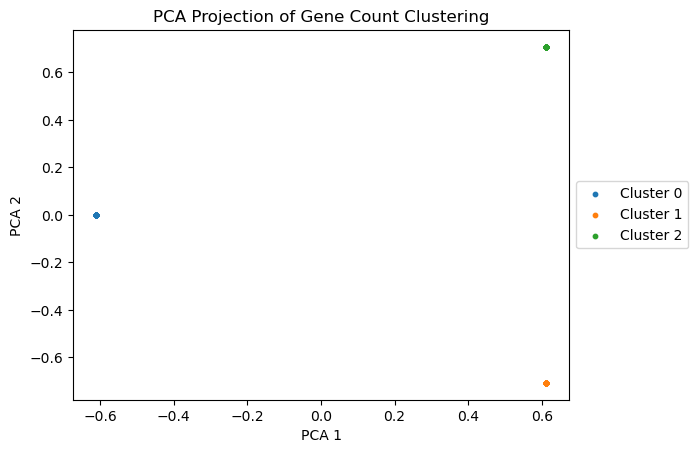

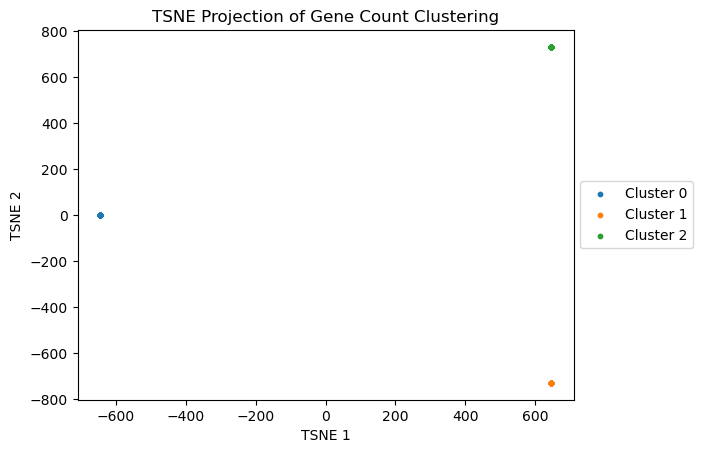

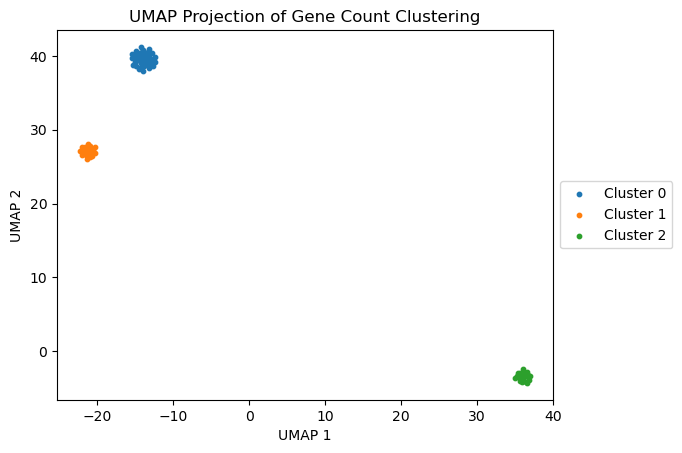

In [36]:
# Cluster the scaled-count PCA representation.
# Construct a k-nearest-neighbor graph
knn_graph = kneighbors_graph(pcs, n_neighbors=20, metric='cosine', mode='connectivity', include_self=True)
# Convert the sparse adjacency matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)
# Detect graph communities with the Louvain algorithm
partition = cl.best_partition(G, random_state=42)  # Using a fixed random state for reproducibility
# Calculate partition modularity
cl.modularity(partition, G)
# Extract one cluster label per cell
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of Gene Count Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # TSNE 1 values for this cluster
        embedding[cluster_labels == label, 1],  # TSNE 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of Gene Count Clustering')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding_umap[cluster_labels == label, 0],  # UMAP 1 values for this cluster
        embedding_umap[cluster_labels == label, 1],  # UMAP 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('UMAP Projection of Gene Count Clustering')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

#### Compare Clusters with the Ground-Truth Reference Groups

The Jaccard matrix is reordered with the Hungarian assignment so that the best cluster-to-group matches appear together.

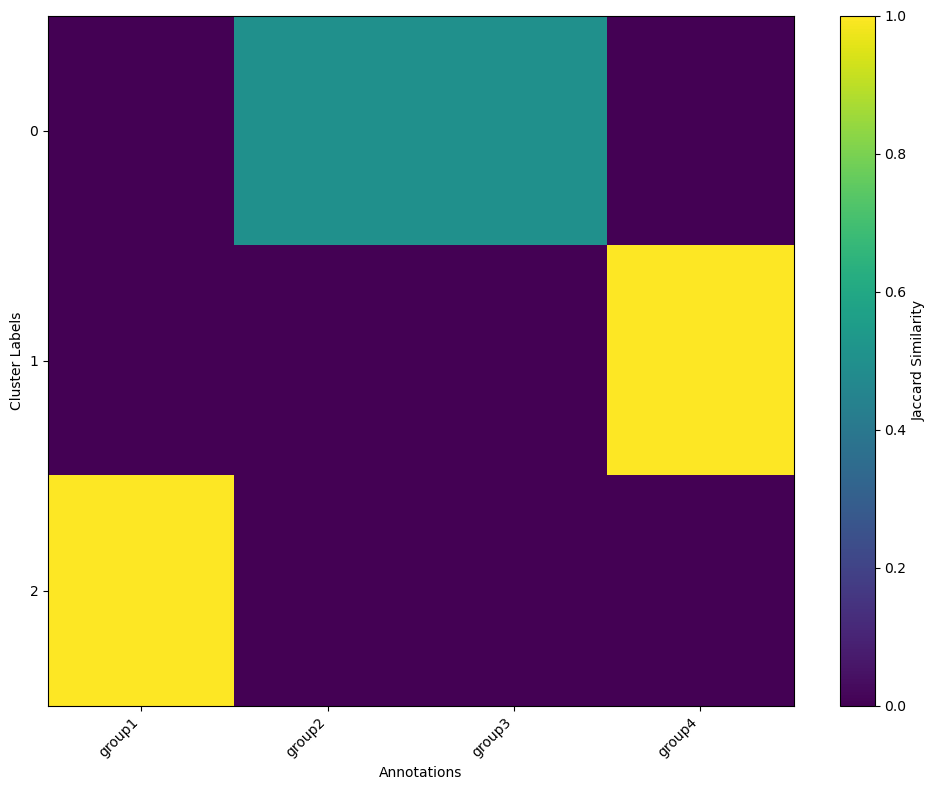

In [37]:
# Display cluster-to-annotation overlap for scaled counts.
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

#### Report Agreement Metrics

The adjusted Rand index (ARI) measures pairwise agreement while correcting for chance. The matched Jaccard scores summarize membership overlap for the optimal cluster-to-group assignment. Values closer to 1 indicate stronger recovery of the simulated groups.

In [38]:
# Report agreement metrics for scaled counts.
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(np.array(annotations), cluster_labels)}")
average_jaccard, matched_scores = calculate_average_diagonal_jaccard(cluster_labels, np.array(annotations))
print(f"Matched Scores: {matched_scores}")
print(f"Average Diagonal Jaccard Similarity: {average_jaccard}")

Adjusted Rand Index (ARI): 0.7063197026022305
Matched Scores: [0.5 1.  1. ]
Average Diagonal Jaccard Similarity: 0.8333333333333334


##### Interpretation
When we represent this simulated imSRT dataset as conventional gene counts (both raw and scaled) and perform PCA dimensionality reduction and Louvain graph-based clustering, we are only able to identify three clusters of cells that correspond to the three simulated transcriptionally distinct cell-types. In contrast, when we apply STARIT, using the ResNet101 model for feature extraction followed by the same dimensionality reduction and clustering, we are able to identify four clusters of cells corresponding to the four simulated groups of cells representing cell-types and cell states with distinct subcellular heterogeneity.